In [19]:
import os
import re
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from sklearn.model_selection import train_test_split
from tqdm import tqdm

np.random.seed(18)

TOKENIZER(QCD AND QED)

def get_token_types-->
        
        It assigns a physics type label to every token.
        Used by the physics-informed attention layer in the model.

        Type 0 = MOMENTUM   (Mandelstam <S>,<T>,<U> + MOMENTUM_N)
        Type 1 = MASS       (m_e, m_u, m_t, reg_prop)
        Type 2 = OPERATOR   (gamma, sigma, eta matrices, color factors)
        Type 3 = INDEX      (INDEX_N, PINDEX_N)
        Type 4 = ALGEBRAIC  (+, -, *, /, ^, numbers, fractions)
        Type 5 = SPECIAL    (<BOS>, <EOS>, <PAD>, etc.)
        

Physics Informed Mandelstam Encoding

In [20]:
class AmplitudeTokenizer:
    def __init__(self, index_pool_size=100, special_symbols=None, to_replace=True):
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace

        if special_symbols is None:
            self.special_symbols = [
                '<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>',
                '<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'
            ]
        else:
            self.special_symbols = special_symbols

        self.index_pool = [f"INDEX_{i}" for i in range(index_pool_size)]
        self.particle_index_pool = [f"PINDEX_{i}" for i in range(index_pool_size)]

        self.pattern_particle = re.compile(r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)')
        self.pattern_num_123 = re.compile(r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b')
        self.pattern_momentum = re.compile(r'[ps]_(\d+)')

    @staticmethod
    def remove_whitespace(text):
        return re.sub(r'\s+', '', text)

    @staticmethod
    def split_expression(text):
        return re.split(r' ', text)

    def normalize_indices(self, text):
        if not self.to_replace:
            return text

        text = self.remove_whitespace(text)

        text = re.sub(r'\bs_(\d{2,})\b', lambda m: f'__MAND_{m.group(1)}__', text)

        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r'\bs_(\d+)\b', r'MOMENTUM_\1', text)

        text = re.sub(r'__MAND_(\d+)__', r's_\1', text)

        text = text.replace('\\\\', '\\').replace('\\', r' \ ').replace('%', ' % ')

        index_matches = list(OrderedDict.fromkeys(
            self.pattern_num_123.findall(text)
        ))

        index_iter = iter(self.index_pool)
        index_mapping = {}
        for match in index_matches:
            try:
                index_mapping[match] = next(index_iter)
            except StopIteration:
                raise RuntimeError(f"Index pool exhausted. Increase index_pool_size (currently {self.index_pool_size})")

        for old, new in sorted(index_mapping.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        particle_matches = list(OrderedDict.fromkeys(
            m.group('target')
            for m in sorted(self.pattern_particle.finditer(text), key=lambda m: m.start())
        ))

        particle_iter = iter(self.particle_index_pool)
        particle_mapping = {}
        for match in particle_matches:
            try:
                particle_mapping[match] = next(particle_iter)
            except StopIteration:
                raise RuntimeError("Particle index pool exhausted. Increase index_pool_size")

        for old, new in sorted(particle_mapping.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        return text

    def tokenize_amplitude(self, amplitude_text):
        if self.to_replace:
            text = self.normalize_indices(amplitude_text)
        else:
            text = amplitude_text

        text = self.remove_whitespace(text)

        text = text.replace('\\\\', '\\').replace('\\', r' \ ').replace('%', ' % ')
        text = text.replace("(*)", " CONJ ")
        text = text.replace("(theta_W)", "_theta_W")

        for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
            text = text.replace(symbol, f' {symbol} ')

        text = text.replace("_PINDEX", "_ PINDEX").replace("_INDEX", "_ INDEX")
        text = text.replace("reg_prop", " reg_prop ")

        text = re.sub(r' {2,}', ' ', text)

        tokens = [t for t in self.split_expression(text) if t]
        tokens = self.tag_mandelstam(tokens)
        return tokens

    def tokenize_squared(self, squared_text):
      if self.to_replace:
          protected = re.sub(r'\bs_(\d{2,})\b',
                            lambda m: f'__MAND_{m.group(1)}__',
                            squared_text)
          text = self.normalize_indices(protected)
          text = re.sub(r'__MAND_(\d+)__', r's_\1', text)
      else:
          text = squared_text

      text = self.remove_whitespace(text)
      text = text.replace("(theta_W)", "_theta_W")

      for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
          text = text.replace(symbol, f' {symbol} ')

      text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)

      text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)

      text = text.replace("reg_prop", " reg_prop ")
      text = re.sub(r' {2,}', ' ', text)

      tokens = [t for t in self.split_expression(text) if t]
      tokens = self.tag_mandelstam(tokens)
      return tokens

    def tag_mandelstam(self, tokens):
        mandelstam_map = {
            's_12': '<S>',       's_21': '<S>',
            's_13': '<T>',       's_31': '<T>',
            's_14': '<U>',       's_41': '<U>',
            's_23': '<U_CROSS>', 's_32': '<U_CROSS>',
            's_24': '<T_CROSS>', 's_42': '<T_CROSS>',
            's_34': '<S_CROSS>', 's_43': '<S_CROSS>',
        }
        return [mandelstam_map.get(tok, tok) for tok in tokens]

    def get_token_types(self, tokens):
        MOMENTUM_TOKENS = {
            '<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'
        }
        SPECIAL_TOKENS = {
            '<PAD>', '<UNK>', '<BOS>', '<EOS>',
            '<SEP>', '<TERM0>', '<TERM1>'
        }
        ALGEBRAIC = {'+', '-', '*', '/', '^', '(', ')', ',', '=', '[', ']', '\\'}

        type_labels = []
        for tok in tokens:
            if tok in MOMENTUM_TOKENS or tok.startswith('MOMENTUM_'):
                type_labels.append(0)
            elif tok.startswith('m_') or tok == 'reg_prop':
                type_labels.append(1)
            elif any(x in tok for x in ['gamma', 'sigma', 'eta', 'eps', 'del',
                                         'tau', 'mu', 'rho', 'gam', 'vho', 'CONJ',
                                         'T_C', 'G_{']):
                type_labels.append(2)
            elif tok.startswith('INDEX_') or tok.startswith('PINDEX_'):
                type_labels.append(3)
            elif tok in SPECIAL_TOKENS:
                type_labels.append(5)
            else:
                type_labels.append(4)
        return type_labels

    def tokenize_with_types(self, amplitude_text):
        tokens = self.tokenize_amplitude(amplitude_text)
        types = self.get_token_types(tokens)
        return tokens, types

Vocabulary for our data

In [21]:
class Vocabulary:

    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=[5,6]):

        tokens = list(tokens)
        for special in special_symbols:
            if special in tokens:
                tokens.remove(special)

        self.token_list = special_symbols + tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.token_list)}
        self.idx_to_token = {idx: token for token, idx in self.token_to_idx.items()}

        self.pad_idx = pad_idx
        self.unk_idx = unk_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.sep_idx = sep_idx
        self.term_idx = term_idx

        self.pad_tok = special_symbols[pad_idx]
        self.unk_tok = special_symbols[unk_idx]
        self.bos_tok = special_symbols[bos_idx]
        self.eos_tok = special_symbols[eos_idx]
        self.sep_tok = special_symbols[sep_idx]

        self.special_indices = set(self.token_to_idx[sym] for sym in special_symbols)

    def encode(self, tokens):
        return [self.token_to_idx.get(token, self.unk_idx) for token in tokens]

    def decode(self, indices, include_special=True):
        if include_special:
            return [self.idx_to_token.get(idx, self.unk_tok) for idx in indices]
        else:
            return [
                self.idx_to_token.get(idx, self.unk_tok)
                for idx in indices
                if idx not in self.special_indices or idx == self.sep_idx
            ]

    def __len__(self):
        return len(self.token_list)

    def __getitem__(self, item):
        if isinstance(item, int):
            return self.idx_to_token.get(item, self.unk_tok)
        return self.token_to_idx.get(item, self.unk_idx)

    def tokens(self):
        return self.token_list

Loading the data

In [22]:
DATA_DIR = "./data/raw"
os.makedirs(DATA_DIR, exist_ok=True)

In [23]:
all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.txt')]
print(f"Found {len(all_files)} files:")
for f in sorted(all_files):
    print(f"  - {f}")

# Separate QED and QCD
qed_files = [f for f in all_files if 'QED' in f]
qcd_files = [f for f in all_files if 'QCD' in f]
print(f"\nQED files: {len(qed_files)}")
print(f"QCD files: {len(qcd_files)}")

Found 17 files:
  - QCD-2-to-2-diag-TreeLevel-0.txt
  - QCD-2-to-2-diag-TreeLevel-1.txt
  - QCD-2-to-2-diag-TreeLevel-2.txt
  - QCD-2-to-2-diag-TreeLevel-3.txt
  - QCD-2-to-2-diag-TreeLevel-4.txt
  - QCD-2-to-2-diag-TreeLevel-5.txt
  - QCD-2-to-2-diag-TreeLevel-6.txt
  - QED-2-to-2-diag-TreeLevel-0.txt
  - QED-2-to-2-diag-TreeLevel-1.txt
  - QED-2-to-2-diag-TreeLevel-2.txt
  - QED-2-to-2-diag-TreeLevel-3.txt
  - QED-2-to-2-diag-TreeLevel-4.txt
  - QED-2-to-2-diag-TreeLevel-5.txt
  - QED-2-to-2-diag-TreeLevel-6.txt
  - QED-2-to-2-diag-TreeLevel-7.txt
  - QED-2-to-2-diag-TreeLevel-8.txt
  - QED-2-to-2-diag-TreeLevel-9.txt

QED files: 10
QCD files: 7


In [24]:
def load_file(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line_num, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            parts = line.split(' : ')
            if len(parts) == 4:
                interaction, diagram, amplitude, squared = parts
                data.append({
                    'interaction': interaction,
                    'diagram': diagram,
                    'amplitude': amplitude,
                    'squared_amplitude': squared,
                    'source_file': os.path.basename(filepath),
                    'line_num': line_num
                })
            else:
                print(f"Warning: Skipping malformed line {line_num} in {filepath}")
    return pd.DataFrame(data)

print("Loading QED files...")
qed_dfs = []
for file in tqdm(qed_files):
    df = load_file(os.path.join(DATA_DIR, file))
    qed_dfs.append(df)
qed_data = pd.concat(qed_dfs, ignore_index=True)
print(f"Total QED samples: {len(qed_data)}")

print("\nLoading QCD files...")
qcd_dfs = []
for file in tqdm(qcd_files):
    df = load_file(os.path.join(DATA_DIR, file))
    qcd_dfs.append(df)
qcd_data = pd.concat(qcd_dfs, ignore_index=True)
print(f"Total QCD samples: {len(qcd_data)}")

Loading QED files...


100%|██████████| 10/10 [00:00<00:00, 470.70it/s]


Total QED samples: 360

Loading QCD files...


100%|██████████| 7/7 [00:00<00:00, 618.47it/s]

Total QCD samples: 234


In [25]:
# Combine all data
all_data = pd.concat([qed_data, qcd_data], ignore_index=True)
print(f"\nTotal samples: {len(all_data)}")
print(f"  QED: {len(qed_data)} ({len(qed_data)/len(all_data)*100:.1f}%)")
print(f"  QCD: {len(qcd_data)} ({len(qcd_data)/len(all_data)*100:.1f}%)")


Total samples: 594
  QED: 360 (60.6%)
  QCD: 234 (39.4%)


In [26]:
# Display a few samples
print("Sample data (first 3 rows):")
display(all_data[['interaction', 'diagram', 'amplitude', 'squared_amplitude']].head(3))

# Check for missing values
print("\nMissing values:")
print(all_data.isnull().sum())

Sample data (first 3 rows):


,interaction,diagram,amplitude,squared_amplitude
0,Interaction: u_eps_34(X)^(*) AntiPart u_eta_...,"Vertex V_0:e(X_3), AntiPart e(X_4), OffShell ...","1/3*i*e^2*gamma_{+%\sigma_155,%eta_118,%gam_13...",1/9*e^4*(16*m_e^2*m_u^2 + 8*m_e^2*s_12 + 8*s_1...
1,Interaction: u_alpha_175(X)^(*) AntiPart u_b...,"Vertex V_0:mu(X_3), AntiPart mu(X_4), OffShel...","1/3*i*e^2*gamma_{+%\mu_293,%eta_230,%eta_231}*...",1/9*e^4*(16*m_u^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s...
2,Interaction: u_gam_299(X)^(*) AntiPart u_del...,"Vertex V_0:t(X_3), AntiPart t(X_4), OffShell ...","1/3*i*e^2*gamma_{+%\tau_520,%eta_331,%eps_140}...",1/9*e^4*(16*m_t^2*m_u^2 + 8*m_t^2*s_12 + 8*s_1...



Missing values:
interaction          0
diagram              0
amplitude            0
squared_amplitude    0
source_file          0
line_num             0
dtype: int64


Tokenizer testing

In [27]:
# Create tokenizer instance
tokenizer = AmplitudeTokenizer(index_pool_size=1000, to_replace=True)
print("Tokenizer initialized with:")
print(f"  - Index pool size: {tokenizer.index_pool_size}")
print(f"  - Replace indices: {tokenizer.to_replace}")

Tokenizer initialized with:
  - Index pool size: 1000
  - Replace indices: True


In [28]:
example = all_data.iloc[0]
test_amplitude = example['amplitude']
test_squared = example['squared_amplitude']

# Normalize
norm_amp = tokenizer.normalize_indices(test_amplitude)
norm_sq = tokenizer.normalize_indices(test_squared)

print("Original amplitude (first 150 chars):")
print(test_amplitude[:150])
print("\nNormalized amplitude (first 100 chars):")
print(norm_amp[:100])
print("\nNotice: indices like _60 → INDEX_0, etc.")

# Tokenize
amp_tokens = tokenizer.tokenize_amplitude(test_amplitude)
sq_tokens = tokenizer.tokenize_squared(test_squared)
print(f"\nAmplitude tokens ({len(amp_tokens)} tokens):")
print(amp_tokens[:30])
print(f"\nSquared amplitude tokens ({len(sq_tokens)} tokens):")
print(sq_tokens[:30])

Original amplitude (first 150 chars):
1/3*i*e^2*gamma_{+%\sigma_155,%eta_118,%gam_137}*gamma_{%\sigma_155,%gam_138,%eta_119}*e_{l_3,%gam_138}(p_3)_u^(*)*e_{j_5,%eta_119}(p_4)_v*u_{i_3,%gam

Normalized amplitude (first 100 chars):
1/3*i*e^2*gamma_{+ %  \ INDEX_0, % INDEX_1, % INDEX_2}*gamma_{ %  \ INDEX_0, % INDEX_3, % INDEX_4}*e

Notice: indices like _60 → INDEX_0, etc.

Amplitude tokens (92 tokens):
['1', '/', '3', '*', 'i', '*', 'e', '^', '2', '*', 'gamma_{', '+', '%', '\\', 'INDEX_0', ',', '%', 'INDEX_1', ',', '%', 'INDEX_2', '}', '*', 'gamma_{', '%', '\\', 'INDEX_0', ',', '%', 'INDEX_3']

Squared amplitude tokens (66 tokens):
['1', '/', '9', '*', 'e', '^', '4', '*', '(', '16', '*', 'm_e', '^', '2', '*', 'm_u', '^', '2', '+', '8', '*', 'm_e', '^', '2', '*', '<S>', '+', '8', '*', '<U>']


Applying normalization and tokenization to all QED and QCD samples.

In [29]:
qed_processed = qed_data.copy()

tqdm.pandas(desc="Normalizing QED amplitudes")
qed_processed['amplitude_norm'] = qed_processed['amplitude'].progress_apply(tokenizer.normalize_indices)

tqdm.pandas(desc="Normalizing QED squared")
qed_processed['squared_norm'] = qed_processed['squared_amplitude'].progress_apply(tokenizer.normalize_indices)


tqdm.pandas(desc="Tokenizing QED amplitudes with types")
qed_processed['amp_tokens_types'] = qed_processed['amplitude_norm'].progress_apply(tokenizer.tokenize_with_types)
qed_processed['amp_tokens'] = qed_processed['amp_tokens_types'].apply(lambda x: x[0])
qed_processed['amp_types'] = qed_processed['amp_tokens_types'].apply(lambda x: x[1])


tqdm.pandas(desc="Tokenizing QED squared")
qed_processed['sq_tokens'] = qed_processed['squared_norm'].progress_apply(tokenizer.tokenize_squared)

qed_processed = qed_processed.drop('amp_tokens_types', axis=1)

Tokenizing QED squared: 100%|██████████| 360/360 [00:00<00:00, 1313.33it/s]


In [30]:
qcd_processed = qcd_data.copy()

tqdm.pandas(desc="Normalizing QCD amplitudes")
qcd_processed['amplitude_norm'] = qcd_processed['amplitude'].progress_apply(tokenizer.normalize_indices)

tqdm.pandas(desc="Normalizing QCD squared")
qcd_processed['squared_norm'] = qcd_processed['squared_amplitude'].progress_apply(tokenizer.normalize_indices)


tqdm.pandas(desc="Tokenizing QCD amplitudes with types")
qcd_processed['amp_tokens_types'] = qcd_processed['amplitude_norm'].progress_apply(tokenizer.tokenize_with_types)
qcd_processed['amp_tokens'] = qcd_processed['amp_tokens_types'].apply(lambda x: x[0])
qcd_processed['amp_types'] = qcd_processed['amp_tokens_types'].apply(lambda x: x[1])


tqdm.pandas(desc="Tokenizing QCD squared")
qcd_processed['sq_tokens'] = qcd_processed['squared_norm'].progress_apply(tokenizer.tokenize_squared)


qcd_processed = qcd_processed.drop('amp_tokens_types', axis=1)

Tokenizing QCD squared: 100%|██████████| 234/234 [00:00<00:00, 1869.54it/s]


Vocabularies for QED and QCD

In [31]:
# Collect all tokens for QED
print("Building QED vocabularies...")
all_qed_amp_tokens = []
for tokens in tqdm(qed_processed['amp_tokens'], desc="Collecting QED amp tokens"):
    all_qed_amp_tokens.extend(tokens)

all_qed_sq_tokens = []
for tokens in tqdm(qed_processed['sq_tokens'], desc="Collecting QED sq tokens"):
    all_qed_sq_tokens.extend(tokens)

qed_amp_unique = sorted(set(all_qed_amp_tokens))
qed_sq_unique = sorted(set(all_qed_sq_tokens))
print(f"QED - Unique amplitude tokens: {len(qed_amp_unique)}")
print(f"QED - Unique squared tokens: {len(qed_sq_unique)}")

Building QED vocabularies...


QED - Unique amplitude tokens: 118
QED - Unique squared tokens: 36


In [32]:
# Collect all tokens for QCD
print("\nBuilding QCD vocabularies...")
all_qcd_amp_tokens = []
for tokens in tqdm(qcd_processed['amp_tokens'], desc="Collecting QCD amp tokens"):
    all_qcd_amp_tokens.extend(tokens)

all_qcd_sq_tokens = []
for tokens in tqdm(qcd_processed['sq_tokens'], desc="Collecting QCD sq tokens"):
    all_qcd_sq_tokens.extend(tokens)

qcd_amp_unique = sorted(set(all_qcd_amp_tokens))
qcd_sq_unique = sorted(set(all_qcd_sq_tokens))
print(f"QCD - Unique amplitude tokens: {len(qcd_amp_unique)}")
print(f"QCD - Unique squared tokens: {len(qcd_sq_unique)}")


Building QCD vocabularies...


QCD - Unique amplitude tokens: 131
QCD - Unique squared tokens: 60


In [33]:
# Define special symbols (must match those used in tokenizer)
special_symbols = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>']

# Build QED vocabularies
qed_src_vocab = Vocabulary(qed_amp_unique, special_symbols,
                            pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=[5,6])
qed_tgt_vocab = Vocabulary(qed_sq_unique, special_symbols,
                            pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=[5,6])

# Build QCD vocabularies
qcd_src_vocab = Vocabulary(qcd_amp_unique, special_symbols,
                            pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=[5,6])
qcd_tgt_vocab = Vocabulary(qcd_sq_unique, special_symbols,
                            pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=[5,6])

print("\nVocabulary sizes:")
print(f"QED - Source: {len(qed_src_vocab)}, Target: {len(qed_tgt_vocab)}")
print(f"QCD - Source: {len(qcd_src_vocab)}, Target: {len(qcd_tgt_vocab)}")


Vocabulary sizes:
QED - Source: 125, Target: 43
QCD - Source: 138, Target: 67


Train Test Validation (80/10/10)

In [34]:
# Split QED data
print("Splitting QED data...")
qed_train, qed_temp = train_test_split(qed_processed, test_size=0.2, random_state=42, shuffle=True)
qed_val, qed_test = train_test_split(qed_temp, test_size=0.5, random_state=42, shuffle=True)
print(f"QED - Train: {len(qed_train)}, Val: {len(qed_val)}, Test: {len(qed_test)}")

Splitting QED data...
QED - Train: 288, Val: 36, Test: 36


In [35]:
# Split QCD data
print("\nSplitting QCD data...")
qcd_train, qcd_temp = train_test_split(qcd_processed, test_size=0.2, random_state=42, shuffle=True)
qcd_val, qcd_test = train_test_split(qcd_temp, test_size=0.5, random_state=42, shuffle=True)
print(f"QCD - Train: {len(qcd_train)}, Val: {len(qcd_val)}, Test: {len(qcd_test)}")


Splitting QCD data...
QCD - Train: 187, Val: 23, Test: 24


Analyzing the sequence length

In [36]:
# Add length columns to training sets (for analysis)
qed_train = qed_train.copy()
qed_train['amp_len'] = qed_train['amp_tokens'].apply(len)
qed_train['sq_len'] = qed_train['sq_tokens'].apply(len)

qcd_train = qcd_train.copy()
qcd_train['amp_len'] = qcd_train['amp_tokens'].apply(len)
qcd_train['sq_len'] = qcd_train['sq_tokens'].apply(len)

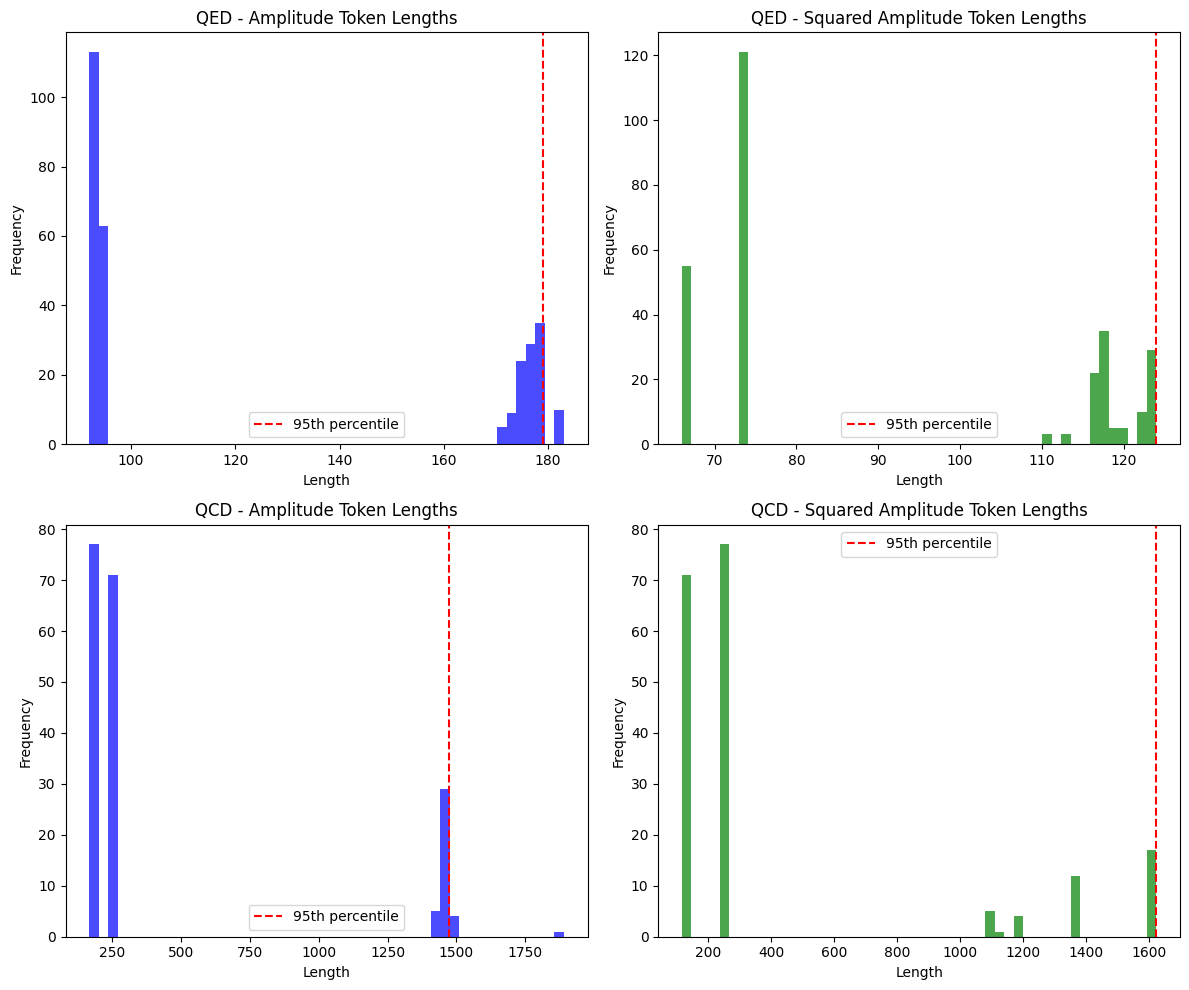

In [37]:
# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# QED Amplitude
axes[0,0].hist(qed_train['amp_len'], bins=50, alpha=0.7, color='blue')
axes[0,0].set_title('QED - Amplitude Token Lengths')
axes[0,0].set_xlabel('Length')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(qed_train['amp_len'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
axes[0,0].legend()

# QED Squared
axes[0,1].hist(qed_train['sq_len'], bins=50, alpha=0.7, color='green')
axes[0,1].set_title('QED - Squared Amplitude Token Lengths')
axes[0,1].set_xlabel('Length')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(qed_train['sq_len'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
axes[0,1].legend()

# QCD Amplitude
axes[1,0].hist(qcd_train['amp_len'], bins=50, alpha=0.7, color='blue')
axes[1,0].set_title('QCD - Amplitude Token Lengths')
axes[1,0].set_xlabel('Length')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(qcd_train['amp_len'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
axes[1,0].legend()

# QCD Squared
axes[1,1].hist(qcd_train['sq_len'], bins=50, alpha=0.7, color='green')
axes[1,1].set_title('QCD - Squared Amplitude Token Lengths')
axes[1,1].set_xlabel('Length')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(qcd_train['sq_len'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150)
plt.show()

In [38]:
# Print statistics
print("QED Length Statistics:")
print(f"  Amplitude - Mean: {qed_train['amp_len'].mean():.1f}, Max: {qed_train['amp_len'].max()}, 95th: {qed_train['amp_len'].quantile(0.95):.0f}")
print(f"  Squared   - Mean: {qed_train['sq_len'].mean():.1f}, Max: {qed_train['sq_len'].max()}, 95th: {qed_train['sq_len'].quantile(0.95):.0f}")

print("\nQCD Length Statistics:")
print(f"  Amplitude - Mean: {qcd_train['amp_len'].mean():.1f}, Max: {qcd_train['amp_len'].max()}, 95th: {qcd_train['amp_len'].quantile(0.95):.0f}")
print(f"  Squared   - Mean: {qcd_train['sq_len'].mean():.1f}, Max: {qcd_train['sq_len'].max()}, 95th: {qcd_train['sq_len'].quantile(0.95):.0f}")

QED Length Statistics:
  Amplitude - Mean: 125.7, Max: 183, 95th: 179
  Squared   - Mean: 89.7, Max: 124, 95th: 124

QCD Length Statistics:
  Amplitude - Mean: 469.1, Max: 1890, 95th: 1472
  Squared   - Mean: 443.3, Max: 1622, 95th: 1622


Saving the Processed Data

In [39]:
# Create output directory
os.makedirs('./data/processed', exist_ok=True)

# Prepare data dictionary
processed_data = {
    'qed': {
        'train': qed_train.to_dict('records'),
        'val': qed_val.to_dict('records'),
        'test': qed_test.to_dict('records'),
        'src_vocab': qed_src_vocab,
        'tgt_vocab': qed_tgt_vocab
    },
    'qcd': {
        'train': qcd_train.to_dict('records'),
        'val': qcd_val.to_dict('records'),
        'test': qcd_test.to_dict('records'),
        'src_vocab': qcd_src_vocab,
        'tgt_vocab': qcd_tgt_vocab
    },
    'tokenizer': tokenizer,
    'metadata': {
        'index_pool_size': tokenizer.index_pool_size,
        'special_symbols': special_symbols,
        'total_samples': len(all_data),
        'qed_samples': len(qed_data),
        'qcd_samples': len(qcd_data),
        'qed_src_vocab_size': len(qed_src_vocab),
        'qed_tgt_vocab_size': len(qed_tgt_vocab),
        'qcd_src_vocab_size': len(qcd_src_vocab),
        'qcd_tgt_vocab_size': len(qcd_tgt_vocab)
    }
}

# Save as pickle
with open('./data/processed/processed_data2.pkl', 'wb') as f:
    pickle.dump(processed_data, f)

print("✅ Processed data saved to ./data/processed/processed_data2.pkl")

✅ Processed data saved to ./data/processed/processed_data2.pkl
